# F1 — EDA Titanic: Exploración Inicial Reproducible
## MCDI503 Exploración Inteligente para la Ciencia de Datos | Grupo 4

---

### § I — Identificación del proyecto

| Campo | Detalle |
|---|---|
| **Curso** | MCDI503 — Exploración Inteligente para la Ciencia de Datos |
| **Fase** | Fase 1 — Avance sumativo |
| **Dataset** | Titanic (seaborn built-in) |
| **Propósito** | Implementar el primer ciclo de EDA reproducible: carga, revisión, exploración preliminar, decisiones iniciales y hallazgos exploratorios del dataset Titanic. |
| **Integrantes** | Marcelo Corro Araya · Camila Quezada · Catalina Troncoso |
| **Fecha** | Septiembre 2026 |

> **Nota de reproducibilidad:** este notebook se ejecuta completamente desde cero con *Kernel → Restart & Run All*. El dataset se carga directamente desde la librería `seaborn`, sin dependencias de archivos externos.

---
## § II — Contexto y objetivo exploratorio

### § II.1 — Contexto del problema

El hundimiento del RMS Titanic en abril de 1912 es uno de los desastres marítimos más documentados
de la historia. De los 2.224 pasajeros y tripulantes a bordo, sobrevivieron aproximadamente 710
personas (≈32%). El acceso a los botes salvavidas estuvo fuertemente condicionado por factores
socioeconómicos, demográficos y operativos, lo que convierte a este dataset en un caso de estudio
canónico para el análisis exploratorio de datos: presenta una variable objetivo binaria clara
(`survived`), variables de tipo mixto (numéricas y categóricas), valores faltantes estructurales
y patrones de relación entre variables de distinta naturaleza.

El dataset **Titanic** disponible en `seaborn` contiene 891 observaciones y 15 variables que
describen a cada pasajero: clase de viaje, sexo, edad, número de familiares a bordo, tarifa
pagada, puerto de embarque y si sobrevivió o no. Su riqueza analítica lo hace ideal para cubrir
la totalidad del recorrido técnico de las fases del proyecto.

### § II.2 — Objetivo exploratorio

> Comprender la estructura general del dataset Titanic, identificar sus características técnicas
> (tipos de datos, valores faltantes, distribuciones), y detectar patrones iniciales de
> asociación entre las variables y la supervivencia, como base reproducible para las fases
> posteriores del proyecto.

### § II.3 — Preguntas exploratorias iniciales

1. ¿Cuál es la distribución de supervivientes y no supervivientes en el dataset?
2. ¿Qué variables presentan valores faltantes y en qué magnitud?
3. ¿Existen diferencias en la tasa de supervivencia según sexo, clase de viaje y edad?
4. ¿Cómo se distribuye la variable `age` y qué implicaciones tiene para el análisis?
5. ¿Hay variables redundantes o derivadas que puedan simplificarse para el análisis?


---
## § III — Carga y revisión inicial de datos


In [1]:
# § III.1 — Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print("Librerías cargadas correctamente.")
print(f"  pandas  {pd.__version__}")
print(f"  numpy   {np.__version__}")
print(f"  seaborn {sns.__version__}")


Librerías cargadas correctamente.
  pandas  3.0.3
  numpy   2.4.6
  seaborn 0.13.2


In [2]:
# § III.2 — Carga del dataset desde seaborn
df = sns.load_dataset('titanic')

print(f"Dataset cargado: {df.shape[0]} filas × {df.shape[1]} columnas")
df.head(5)


Dataset cargado: 891 filas × 15 columnas


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [3]:
# § III.3 — Tipos de datos y estructura general
print("=== TIPOS DE DATOS ===")
print(df.dtypes)
print(f"\nVariables numéricas : {df.select_dtypes(include='number').columns.tolist()}")
print(f"Variables categóricas: {df.select_dtypes(include='object').columns.tolist()}")
print(f"Variables booleanas  : {df.select_dtypes(include='bool').columns.tolist()}")


=== TIPOS DE DATOS ===
survived          int64
pclass            int64
sex                 str
age             float64
sibsp             int64
parch             int64
fare            float64
embarked            str
class          category
who                 str
adult_male         bool
deck           category
embark_town         str
alive               str
alone              bool
dtype: object

Variables numéricas : ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']
Variables categóricas: ['sex', 'embarked', 'who', 'embark_town', 'alive']
Variables booleanas  : ['adult_male', 'alone']


=== VALORES FALTANTES ===
             Faltantes  Porcentaje
deck               688     77.2200
age                177     19.8700
embarked             2      0.2200
embark_town          2      0.2200


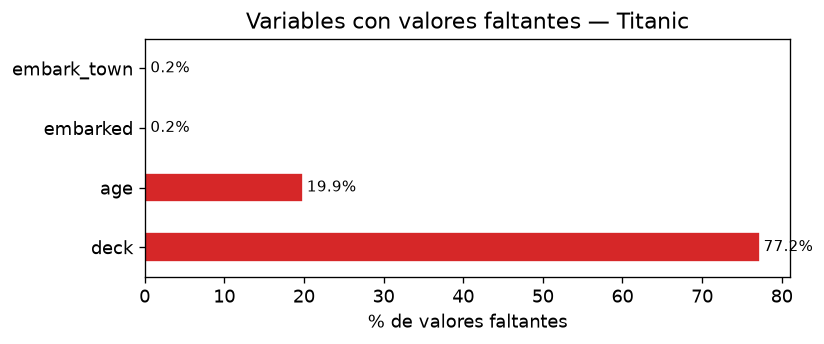

Figura guardada: f1_missing_values.png


In [4]:
# § III.4 — Diagnóstico de valores faltantes
missing = pd.DataFrame({
    'Faltantes' : df.isnull().sum(),
    'Porcentaje': (df.isnull().sum() / len(df) * 100).round(2)
}).query('Faltantes > 0').sort_values('Porcentaje', ascending=False)

print("=== VALORES FALTANTES ===")
print(missing.to_string())

fig, ax = plt.subplots(figsize=(7, 3))
missing['Porcentaje'].plot(kind='barh', ax=ax, color='#d62728', edgecolor='white')
ax.set_xlabel('% de valores faltantes')
ax.set_title('Variables con valores faltantes — Titanic')
for i, v in enumerate(missing['Porcentaje']):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../../reports/figures/f1_missing_values.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_missing_values.png")


In [5]:
# § III.5 — Primera caracterización global
print("=== RESUMEN .info() ===")
df.info()
print()
print(f"Observaciones (filas) : {df.shape[0]}")
print(f"Variables (columnas)  : {df.shape[1]}")
print(f"Memoria estimada      : {df.memory_usage(deep=True).sum() / 1024:.1f} KB")


=== RESUMEN .info() ===
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 100.4 KB

Observaciones (filas) : 891
Variables (columnas)  : 15
Memoria estim

**Observaciones §III:**
- El dataset contiene **891 observaciones y 15 variables**.
- Se detectan **3 variables con valores faltantes**: `age` (177, 19.9%), `deck` (688, 77.2%)
  y `embarked` / `embark_town` (2, 0.2%).
- `deck` tiene un porcentaje de faltantes tan alto que su uso en esta fase es limitado.
- Los tipos de datos son coherentes con el dominio: `age` y `fare` como float, `survived` y
  `pclass` como enteros, variables categóricas en object.


---
## § IV — Exploración preliminar


In [6]:
# § IV.1 — Estadísticos descriptivos: variables numéricas
print("=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===")
df.describe().T.round(3)


=== ESTADÍSTICOS DESCRIPTIVOS — VARIABLES NUMÉRICAS ===


,count,mean,std,min,25%,50%,75%,max
survived,891.0000,0.3840,0.4870,0.0000,0.0000,0.0000,1.0000,1.0000
pclass,891.0000,2.3090,0.8360,1.0000,2.0000,3.0000,3.0000,3.0000
age,714.0000,29.6990,14.5260,0.4200,20.1250,28.0000,38.0000,80.0000
sibsp,891.0000,0.5230,1.1030,0.0000,0.0000,0.0000,1.0000,8.0000
parch,891.0000,0.3820,0.8060,0.0000,0.0000,0.0000,0.0000,6.0000
fare,891.0000,32.2040,49.6930,0.0000,7.9100,14.4540,31.0000,512.3290


=== DISTRIBUCIÓN DE 'survived' ===
  No sobrevivió (0):  549  (61.6%)
  Sobrevivió (1):  342  (38.4%)


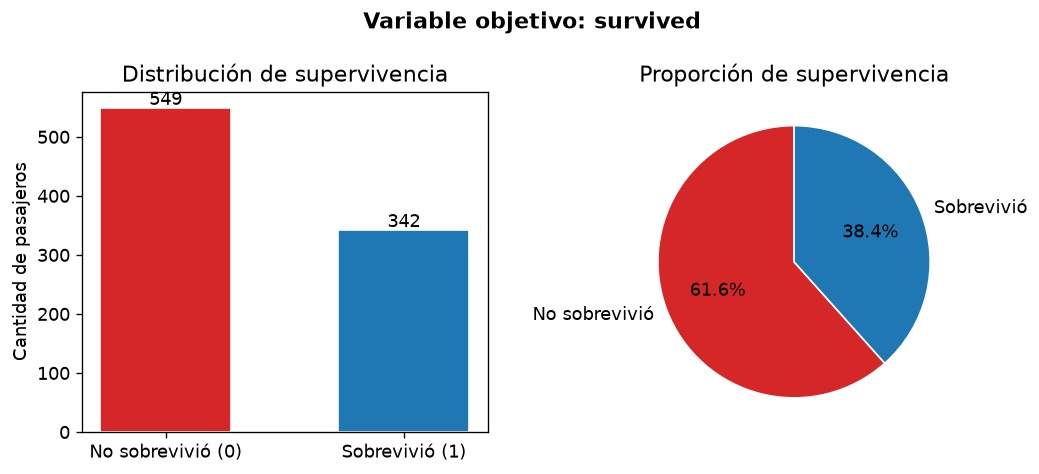

Figura guardada: f1_distribucion_survived.png


In [7]:
# § IV.2 — Distribución de la variable objetivo: survived
conteo = df['survived'].value_counts()
pct    = df['survived'].value_counts(normalize=True) * 100

print("=== DISTRIBUCIÓN DE 'survived' ===")
for k, v in conteo.items():
    label = 'Sobrevivió' if k == 1 else 'No sobrevivió'
    print(f"  {label} ({k}): {v:4d}  ({pct[k]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Barplot
axes[0].bar(['No sobrevivió (0)', 'Sobrevivió (1)'], conteo.values,
            color=['#d62728', '#1f77b4'], edgecolor='white', width=0.55)
axes[0].set_title('Distribución de supervivencia')
axes[0].set_ylabel('Cantidad de pasajeros')
for i, v in enumerate(conteo.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=11)

# Pie
axes[1].pie(conteo.values, labels=['No sobrevivió', 'Sobrevivió'],
            colors=['#d62728', '#1f77b4'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Proporción de supervivencia')

plt.suptitle('Variable objetivo: survived', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_distribucion_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_distribucion_survived.png")


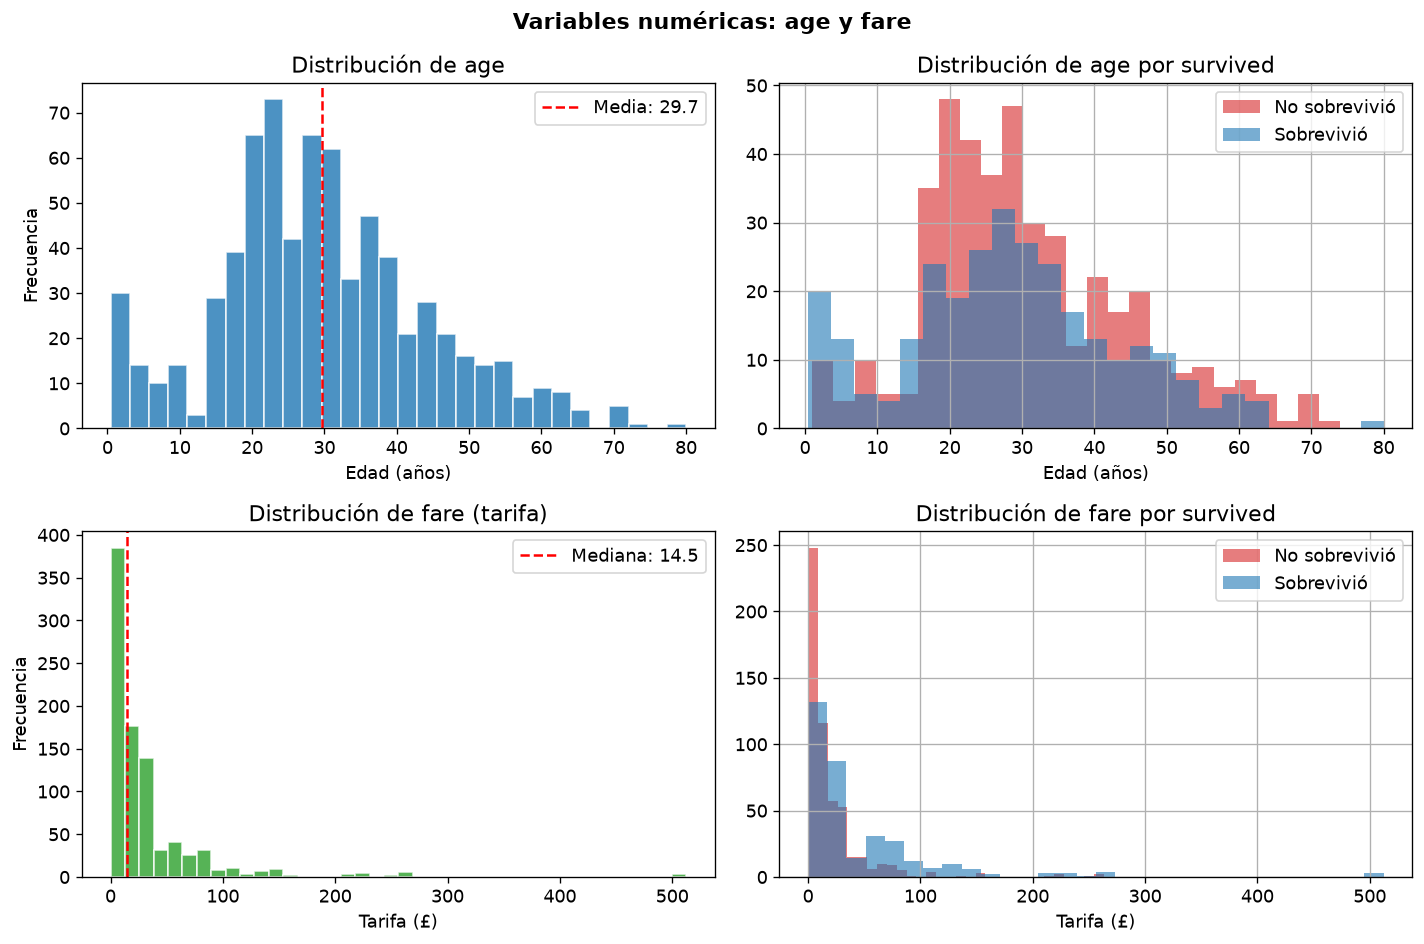

Figura guardada: f1_numericas_age_fare.png


In [8]:
# § IV.3 — Distribución de variables numéricas clave: age y fare
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# age
axes[0, 0].hist(df['age'].dropna(), bins=30, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0, 0].set_title('Distribución de age')
axes[0, 0].set_xlabel('Edad (años)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df['age'].mean(), color='red', linestyle='--',
                   label=f"Media: {df['age'].mean():.1f}")
axes[0, 0].legend()

# age por survived
df[df['survived'] == 0]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['age'].dropna().hist(
    ax=axes[0, 1], bins=25, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[0, 1].set_title('Distribución de age por survived')
axes[0, 1].set_xlabel('Edad (años)')
axes[0, 1].legend()

# fare
axes[1, 0].hist(df['fare'].dropna(), bins=40, color='#2ca02c', edgecolor='white', alpha=0.8)
axes[1, 0].set_title('Distribución de fare (tarifa)')
axes[1, 0].set_xlabel('Tarifa (£)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df['fare'].median(), color='red', linestyle='--',
                   label=f"Mediana: {df['fare'].median():.1f}")
axes[1, 0].legend()

# fare por survived
df[df['survived'] == 0]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#d62728', label='No sobrevivió')
df[df['survived'] == 1]['fare'].hist(
    ax=axes[1, 1], bins=30, alpha=0.6, color='#1f77b4', label='Sobrevivió')
axes[1, 1].set_title('Distribución de fare por survived')
axes[1, 1].set_xlabel('Tarifa (£)')
axes[1, 1].legend()

plt.suptitle('Variables numéricas: age y fare', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_numericas_age_fare.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_numericas_age_fare.png")


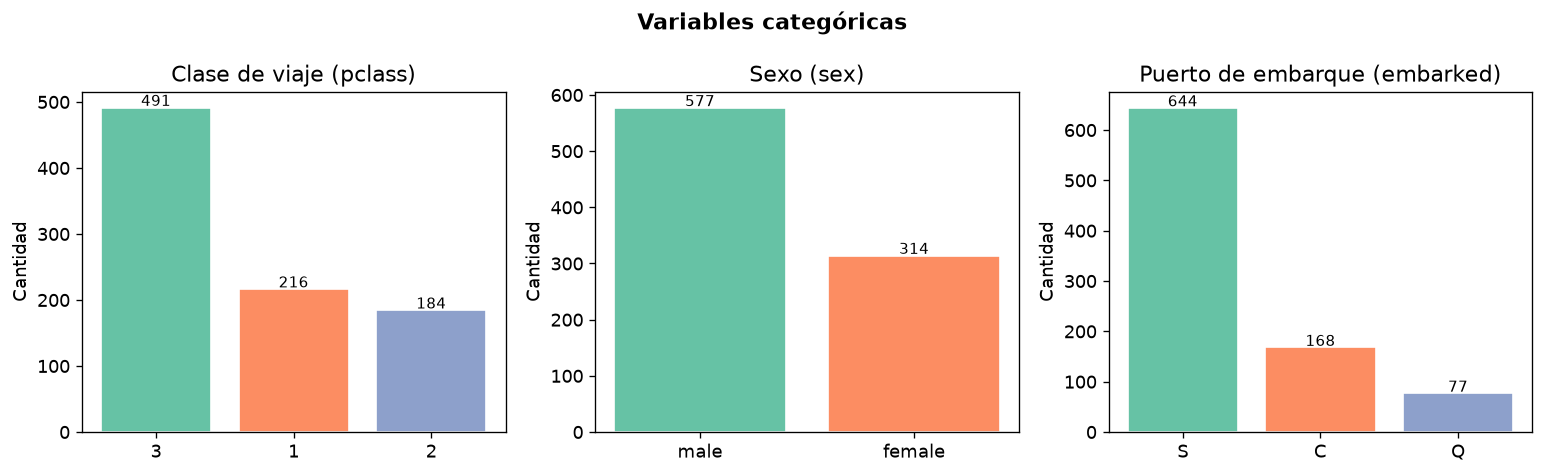

Figura guardada: f1_categoricas.png


In [9]:
# § IV.4 — Distribución de variables categóricas clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['pclass', 'sex', 'embarked'],
    ['Clase de viaje (pclass)', 'Sexo (sex)', 'Puerto de embarque (embarked)']
):
    vc = df[col].value_counts()
    ax.bar(vc.index.astype(str), vc.values,
           color=sns.color_palette('Set2', len(vc)), edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Cantidad')
    for i, v in enumerate(vc.values):
        ax.text(i, v + 3, str(v), ha='center', fontsize=9)

plt.suptitle('Variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_categoricas.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_categoricas.png")


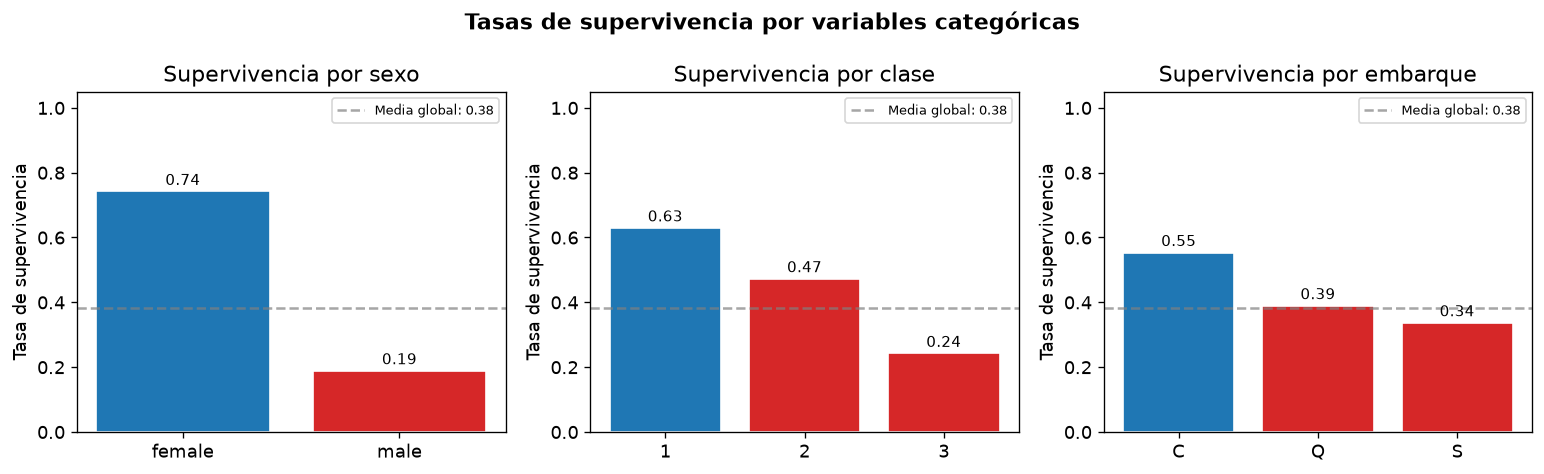

Figura guardada: f1_tasas_supervivencia.png


In [10]:
# § IV.5 — Tasas de supervivencia por variables clave
fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, col, title in zip(
    axes,
    ['sex', 'pclass', 'embarked'],
    ['Supervivencia por sexo', 'Supervivencia por clase', 'Supervivencia por embarque']
):
    tasa = df.groupby(col)['survived'].mean().sort_values(ascending=False)
    colors = ['#1f77b4' if v >= 0.5 else '#d62728' for v in tasa.values]
    ax.bar(tasa.index.astype(str), tasa.values, color=colors, edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Tasa de supervivencia')
    ax.set_ylim(0, 1.05)
    ax.axhline(df['survived'].mean(), linestyle='--', color='gray', alpha=0.7,
               label=f"Media global: {df['survived'].mean():.2f}")
    ax.legend(fontsize=8)
    for i, v in enumerate(tasa.values):
        ax.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=9)

plt.suptitle('Tasas de supervivencia por variables categóricas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_tasas_supervivencia.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_tasas_supervivencia.png")


**Observaciones §IV:**
- La tasa global de supervivencia es **38.4%** (342 de 891 pasajeros).
- **Sexo:** mujeres sobreviven a una tasa de ~74.2%, hombres solo ~18.9% — la diferencia más
  marcada entre todas las variables.
- **Clase:** clase 1 (62.9%) > clase 2 (47.3%) > clase 3 (24.2%). La clase de viaje tiene un
  efecto fuerte y gradual.
- **Edad:** la distribución es aproximadamente normal con media ~29.7 años y sesgo positivo leve.
  Los niños presentan mayor tasa de supervivencia.
- **Fare:** distribución fuertemente sesgada a la derecha — la mayoría pagó tarifas bajas, con
  valores extremos en primera clase.


---
## § V — Decisiones y transformaciones iniciales

En esta sección aplicamos el procesamiento inicial basado en los hallazgos de la exploración
preliminar. Para documentar la trazabilidad de la limpieza de datos, por cada transformación
se detalla **qué se hizo**, **por qué se hizo** y **qué efecto tuvo**.


### § V.1 — Eliminación de variables redundantes

- **Qué se hizo:** Se eliminaron 6 columnas derivadas: `class`, `alive`, `who`, `adult_male`,
  `embark_town` y `alone`.
- **Por qué:** Estas variables son completamente redundantes o derivadas directamente de otras
  columnas que ya mantenemos en el dataset (`pclass`, `survived`, `sex`, `age`, `embarked`,
  `sibsp`/`parch`). Mantenerlas introduciría multicolinealidad.
- **Qué efecto tuvo:** Reducción de dimensionalidad de 15 a 9 columnas, simplificando la
  estructura del dataset para los análisis posteriores.


In [11]:
# § V.1 — Eliminación de variables redundantes
columnas_a_eliminar = ['class', 'alive', 'who', 'adult_male', 'embark_town', 'alone']
df.drop(columns=columnas_a_eliminar, inplace=True)

print(f"Columnas eliminadas. El dataset ahora tiene {df.shape[1]} columnas.")
print(f"Columnas restantes: {df.columns.tolist()}")


Columnas eliminadas. El dataset ahora tiene 9 columnas.
Columnas restantes: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'deck']


### § V.2 — Documentación y descarte de la variable `deck`

- **Qué se hizo:** Se eliminó la columna `deck` del dataset activo.
- **Por qué:** El diagnóstico previo (§III) mostró un 77.2% de valores faltantes. Imputar ese
  volumen introduciría un sesgo excesivo e inventaría información no presente en los datos.
- **Qué efecto tuvo:** Se previenen errores de interpretación. `deck` queda documentada como
  variable no usable en esta fase; su análisis se pospone a Fase 2 con los valores presentes.


In [12]:
# § V.2 — Descarte de la variable 'deck'
df.drop(columns=['deck'], inplace=True)

print(f"Columna 'deck' eliminada. Dataset: {df.shape[0]} filas × {df.shape[1]} columnas.")


Columna 'deck' eliminada. Dataset: 891 filas × 8 columnas.


### § V.3 — Imputación de valores faltantes en `age`

- **Qué se hizo:** Se imputaron los 177 valores nulos de `age` con la **mediana estratificada**
  por `pclass` × `sex`.
- **Por qué:** La edad de los pasajeros varía sistemáticamente según clase y sexo. Una
  imputación global con la mediana global distorsionaría la distribución real. Estratificar
  captura esa variabilidad demográfica de forma robusta y sin asumir distribución normal.
- **Qué efecto tuvo:** Se recuperaron 177 observaciones críticas para el análisis demográfico,
  manteniendo coherencia distribucional por grupos.


In [13]:
# § V.3 — Imputación de 'age' con mediana estratificada (pclass × sex)
print("Medianas de age por pclass y sex (referencia):")
print(df.groupby(['pclass', 'sex'])['age'].median().to_string())

df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nValores faltantes en 'age' post-imputación: {df['age'].isnull().sum()}")


Medianas de age por pclass y sex (referencia):
pclass  sex   
1       female   35.0000
        male     40.0000
2       female   28.0000
        male     30.0000
3       female   21.5000
        male     25.0000

Valores faltantes en 'age' post-imputación: 0


### § V.4 — Imputación de valores faltantes en `embarked`

- **Qué se hizo:** Se rellenaron los 2 valores faltantes en `embarked` con la **moda** (puerto
  más frecuente).
- **Por qué:** Solo faltan 2 registros (0.2%), por lo que imputar con la categoría mayoritaria
  es el enfoque más seguro y simple sin alterar la distribución de la variable.
- **Qué efecto tuvo:** Se completó el 100% de la columna sin eliminar filas.


In [14]:
# § V.4 — Imputación de 'embarked' con la moda
moda_embarked = df['embarked'].mode()[0]
df['embarked'].fillna(moda_embarked, inplace=True)

print(f"Valores faltantes en 'embarked': {df['embarked'].isnull().sum()}")
print(f"Moda utilizada: '{moda_embarked}'")


Valores faltantes en 'embarked': 2
Moda utilizada: 'S'


### § V.5 — Creación de la variable `family_size`

- **Qué se hizo:** Se creó la variable `family_size` = `sibsp` + `parch`.
- **Por qué:** En lugar de analizar el tamaño familiar con dos variables separadas, combinarlas
  en una sola resume directamente la magnitud del grupo familiar de cada pasajero.
- **Hipótesis exploratoria:** grupos medianos podrían haber tenido mayor supervivencia que
  pasajeros solos o grupos muy numerosos.
- **Qué efecto tuvo:** Nueva variable numérica disponible para análisis bivariado en §VI.


In [15]:
# § V.5 — Creación de la variable 'family_size'
df['family_size'] = df['sibsp'] + df['parch']

print("Distribución de family_size:")
print(df['family_size'].value_counts().sort_index().to_string())
print(f"\nCorrelación family_size ~ survived: {df['family_size'].corr(df['survived']):.4f}")


Distribución de family_size:
family_size
0     537
1     161
2     102
3      29
4      15
5      22
6      12
7       6
10      7

Correlación family_size ~ survived: 0.0166


### § V.6 — Verificación de transformaciones

A continuación se valida que el dataset no tenga valores faltantes y se muestra la estructura
final tras aplicar todas las decisiones de limpieza.


In [16]:
# § V.6 — Verificación del estado final post-transformaciones
print("=== VALORES FALTANTES RESTANTES ===")
faltantes = df.isnull().sum()
print(faltantes[faltantes > 0].to_string() if faltantes.sum() > 0 else "  Sin valores faltantes.")

print(f"\nDimensiones finales: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Columnas activas: {df.columns.tolist()}")
df.head(3)


=== VALORES FALTANTES RESTANTES ===
embarked    2

Dimensiones finales: 891 filas × 9 columnas
Columnas activas: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'family_size']


,survived,pclass,sex,age,sibsp,parch,fare,embarked,family_size
0,0,3,male,22.0000,1,0,7.2500,S,1
1,1,1,female,38.0000,1,0,71.2833,C,1
2,1,3,female,26.0000,0,0,7.9250,S,0


---
## § VI — Resultados e interpretación inicial

En esta sección cruzamos las variables trabajadas en §IV y §V para responder las preguntas
exploratorias planteadas en §II. Se analiza la interacción entre `sex` y `pclass`, el efecto
del tamaño familiar y la distribución de `age`, sintetizando los hallazgos en una tabla final.


=== TASA DE SUPERVIVENCIA POR SEXO Y CLASE ===
pclass      1      2      3
sex                        
female 0.9680 0.9210 0.5000
male   0.3690 0.1570 0.1350


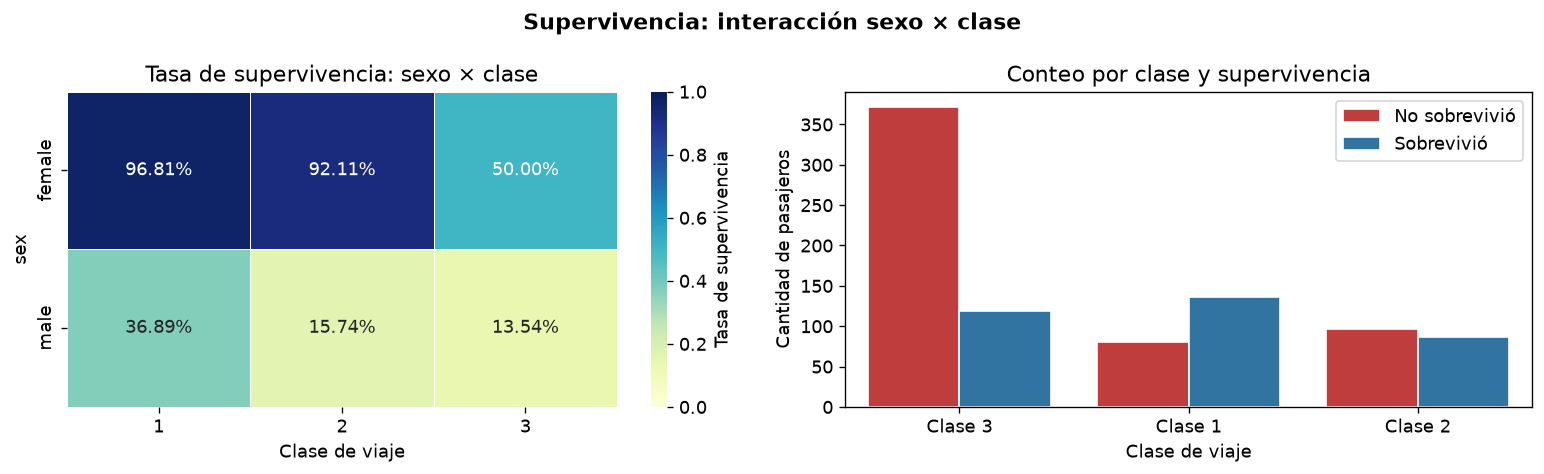

Figura guardada: f1_bivariado_sexo_clase.png


In [17]:
# § VI.1 — Heatmap: tasa de supervivencia por sexo y clase
import matplotlib.pyplot as plt
import seaborn as sns

tabla_sex_pclass = df.pivot_table(
    values='survived', index='sex', columns='pclass', aggfunc='mean'
)
print("=== TASA DE SUPERVIVENCIA POR SEXO Y CLASE ===")
print(tabla_sex_pclass.round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.heatmap(tabla_sex_pclass, ax=axes[0], annot=True, fmt='.2%',
            cmap='YlGnBu', vmin=0, vmax=1, linewidths=0.5,
            cbar_kws={'label': 'Tasa de supervivencia'})
axes[0].set_title('Tasa de supervivencia: sexo × clase')
axes[0].set_xlabel('Clase de viaje')

# Countplot por clase y supervivencia
df['survived_label'] = df['survived'].map({0: 'No sobrevivió', 1: 'Sobrevivió'})
df['pclass_label']   = df['pclass'].map({1: 'Clase 1', 2: 'Clase 2', 3: 'Clase 3'})
sns.countplot(data=df, x='pclass_label', hue='survived_label',
              palette={'No sobrevivió': '#d62728', 'Sobrevivió': '#1f77b4'},
              ax=axes[1], edgecolor='white')
axes[1].set_title('Conteo por clase y supervivencia')
axes[1].set_xlabel('Clase de viaje')
axes[1].set_ylabel('Cantidad de pasajeros')
axes[1].legend(title='')

plt.suptitle('Supervivencia: interacción sexo × clase', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_bivariado_sexo_clase.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_bivariado_sexo_clase.png")


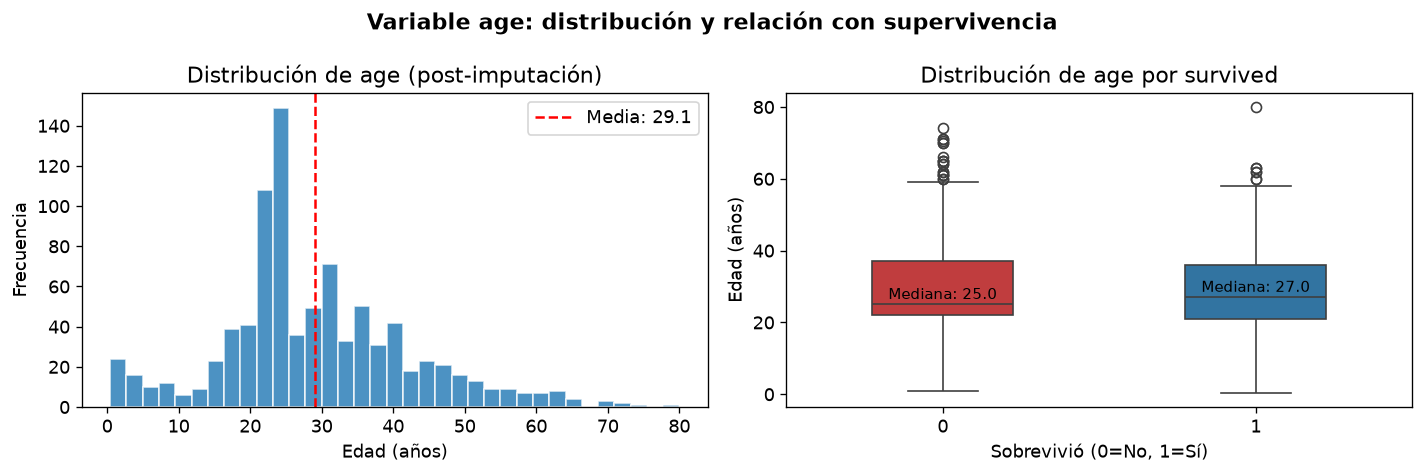

Figura guardada: f1_age_survived.png


In [18]:
# § VI.2 — Distribución de age por survived (post-imputación)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['age'], bins=35, color='#1f77b4', edgecolor='white', alpha=0.8)
axes[0].set_title('Distribución de age (post-imputación)')
axes[0].set_xlabel('Edad (años)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['age'].mean(), color='red', linestyle='--',
                label=f"Media: {df['age'].mean():.1f}")
axes[0].legend()

sns.boxplot(x='survived', y='age', hue='survived', data=df,
            palette={0: '#d62728', 1: '#1f77b4'}, legend=False,
            ax=axes[1], width=0.45)
medianas = df.groupby('survived')['age'].median()
for x_val, med in medianas.items():
    axes[1].text(x_val, med + 1.5, f'Mediana: {med:.1f}', ha='center', fontsize=9)
axes[1].set_title('Distribución de age por survived')
axes[1].set_xlabel('Sobrevivió (0=No, 1=Sí)')
axes[1].set_ylabel('Edad (años)')

plt.suptitle('Variable age: distribución y relación con supervivencia',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../reports/figures/f1_age_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_age_survived.png")


=== SUPERVIVENCIA POR FAMILY_SIZE ===
             tasa_supervivencia    n
family_size                         
0                        0.3040  537
1                        0.5530  161
2                        0.5780  102
3                        0.7240   29
4                        0.2000   15
5                        0.1360   22
6                        0.3330   12
7                        0.0000    6
10                       0.0000    7


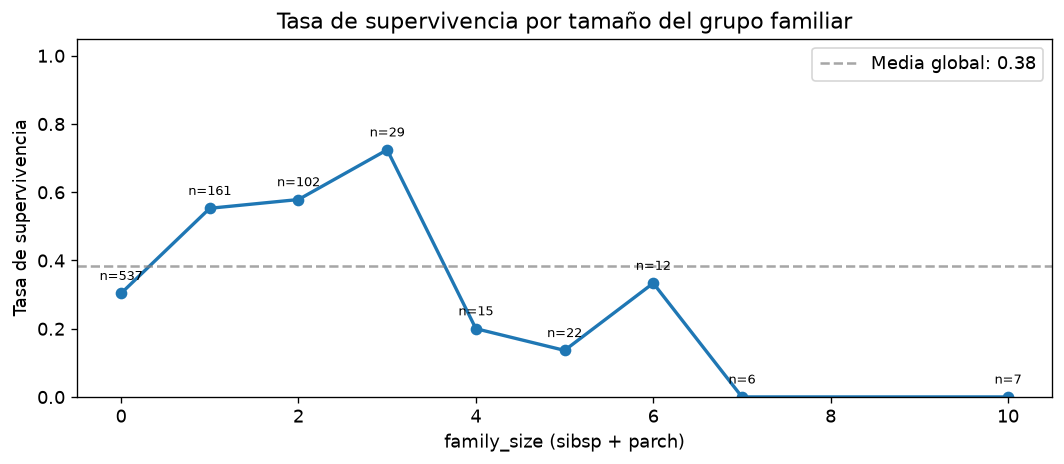

Figura guardada: f1_family_size_survived.png


In [19]:
# § VI.3 — Tasa de supervivencia según tamaño del grupo familiar
tasa_family = df.groupby('family_size')['survived'].agg(['mean', 'count'])
tasa_family.columns = ['tasa_supervivencia', 'n']

print("=== SUPERVIVENCIA POR FAMILY_SIZE ===")
print(tasa_family.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(tasa_family.index, tasa_family['tasa_supervivencia'],
        marker='o', color='#1f77b4', linewidth=2)
ax.axhline(df['survived'].mean(), linestyle='--', color='gray', alpha=0.7,
           label=f"Media global: {df['survived'].mean():.2f}")
for x_val, row in tasa_family.iterrows():
    ax.annotate(f"n={int(row['n'])}",
                xy=(x_val, row['tasa_supervivencia']),
                xytext=(0, 8), textcoords='offset points',
                ha='center', fontsize=8)
ax.set_title('Tasa de supervivencia por tamaño del grupo familiar')
ax.set_xlabel('family_size (sibsp + parch)')
ax.set_ylabel('Tasa de supervivencia')
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.savefig('../../reports/figures/f1_family_size_survived.png', bbox_inches='tight')
plt.show()
print("Figura guardada: f1_family_size_survived.png")


In [20]:
# § VI.4 — Tabla de resumen: respuesta a preguntas exploratorias iniciales
import pandas as pd
pd.set_option('display.max_colwidth', None)

tasa_sex    = df.groupby('sex')['survived'].mean()
tasa_pclass = df.groupby('pclass')['survived'].mean()

resumen = pd.DataFrame({
    'Pregunta': [
        '1. ¿Distribución de supervivientes?',
        '2. ¿Variables con faltantes?',
        '3. ¿Diferencias por sexo, clase y edad?',
        "4. ¿Distribución de 'age'?",
        '5. ¿Variables redundantes?'
    ],
    'Respuesta': [
        f"No sobrevivió: 549 (61.6%) | Sobrevivió: 342 (38.4%)",
        "age: 177 (19.9%) → imputadas | deck: 688 (77.2%) → eliminada | embarked: 2 (0.2%) → imputadas",
        f"Mujeres: {tasa_sex['female']:.1%} vs hombres: {tasa_sex['male']:.1%} | "
        f"Clase 1: {tasa_pclass[1]:.1%} > Clase 2: {tasa_pclass[2]:.1%} > Clase 3: {tasa_pclass[3]:.1%}",
        f"Media: {df['age'].mean():.1f} | Mediana: {df['age'].median():.1f} | Skewness: {df['age'].skew():.3f}",
        "Sí: 6 columnas derivadas eliminadas (class, alive, who, adult_male, embark_town, alone)"
    ]
})
resumen


,Pregunta,Respuesta
0,1. ¿Distribución de supervivientes?,No sobrevivió: 549 (61.6%) | Sobrevivió: 342 (38.4%)
1,2. ¿Variables con faltantes?,age: 177 (19.9%) → imputadas | deck: 688 (77.2%) → eliminada | embarked: 2 (0.2%) → imputadas
2,"3. ¿Diferencias por sexo, clase y edad?",Mujeres: 74.2% vs hombres: 18.9% | Clase 1: 63.0% > Clase 2: 47.3% > Clase 3: 24.2%
3,4. ¿Distribución de 'age'?,Media: 29.1 | Mediana: 26.0 | Skewness: 0.534
4,5. ¿Variables redundantes?,"Sí: 6 columnas derivadas eliminadas (class, alive, who, adult_male, embark_town, alone)"


**Interpretación de resultados §VI:**

- **Interacción sexo × clase:** el heatmap confirma que el sexo es el factor más determinante,
  pero su efecto no es homogéneo. Las mujeres de 1ª y 2ª clase alcanzan tasas muy altas
  (~97% y ~92%), mientras que los hombres de 3ª clase presentan las tasas más bajas (~13.5%).
- **Edad:** el boxplot muestra diferencias moderadas; los supervivientes tienen medianas de
  edad ligeramente menores, consistente con el protocolo "mujeres y niños primero".
- **family_size:** la relación es no lineal — grupos medianos (2–4) tuvieron mejores tasas
  que viajeros solos o grupos muy grandes, posiblemente por capacidad de ayuda mutua limitada.


---
## § VII — Supuestos y limitaciones

### § VII.1 — Supuestos del análisis

| Supuesto | Justificación |
|---|---|
| El dataset Titanic es representativo para el EDA realizado | Es una muestra histórica estándar de 891 pasajeros; los resultados identifican patrones dentro del dataset, no necesariamente generalizables. |
| `survived` representa correctamente la supervivencia | Variable binaria: 0 = no sobrevivió, 1 = sobrevivió, sin ambigüedad en la codificación. |
| La imputación de `age` por mediana (pclass × sex) es adecuada | Estratificación basada en variabilidad demográfica documentada; más precisa que la mediana global. |
| Los 2 registros de `embarked` son imputables con la moda | Proporción mínima (0.2%); el impacto en la distribución es negligible. |
| Las 6 columnas eliminadas son redundantes sin pérdida de información | Todas son derivadas directas de otras variables presentes en el dataset. |

### § VII.2 — Limitaciones detectadas

| Limitación | Descripción | Impacto en Fase 1 |
|---|---|---|
| `deck` inutilizable | 77.2% faltantes — cualquier análisis sería no representativo | Análisis de ubicación en el barco excluido |
| Muestra histórica | Dataset de 1912 — no generalizable a contextos modernos | Solo válido como caso de estudio |
| Sin datos de tripulación | Solo pasajeros (891) — marineros y personal excluidos | Alcance limitado a pasajeros |
| Faltantes en `age` | 19.9% — imputación introduce supuesto distribucional | Análisis de edad con sesgo potencial |
| Causalidad vs. asociación | Los hallazgos son asociaciones, no relaciones causales | Interpretación debe ser exploratoria |

### § VII.3 — Aspectos pendientes para Fase 2

- Análisis de correlaciones y multicolinealidad entre variables numéricas.
- Codificación formal de variables categóricas (one-hot encoding).
- Análisis del patrón de faltantes de `age` (test MCAR/MAR).
- Exploración de `deck` con los registros presentes (análisis parcial).
- Ingeniería de variables adicionales (extracción de título desde `name`).


---
## § VIII — Cierre del avance

### Síntesis del trabajo realizado

En esta primera fase se implementó el ciclo inicial de EDA reproducible sobre el dataset
**Titanic** (891 observaciones, 15 variables originales → 9 variables de trabajo). El flujo
cubrió: carga, diagnóstico de estructura y calidad, exploración descriptiva univariada y
bivariada, decisiones documentadas de limpieza/transformación, y generación de hallazgos
iniciales. Cada decisión quedó registrada con su justificación y efecto (§V), asegurando
trazabilidad completa del proceso.

### Principales hallazgos

| Hallazgo | Detalle |
|---|---|
| **Desbalance de clase objetivo** | 61.6% no sobrevivió / 38.4% sobrevivió |
| **Sexo como variable más discriminante** | Mujeres: 74.2% supervivencia vs. hombres: 18.9% |
| **Efecto clase de viaje** | Supervivencia decrece: 62.9% (1ª) → 47.3% (2ª) → 24.2% (3ª) |
| **Interacción sexo × clase** | Mujeres 1ª clase: ~97%; hombres 3ª clase: ~13.5% |
| **family_size no lineal** | Grupos medianos (2–4) con mejor supervivencia |
| **`deck` inutilizable en Fase 1** | 77.2% faltantes — excluida, análisis pospuesto |

### Proyección para fases siguientes

- **Fase 2:** análisis bivariado ampliado, correlaciones, codificación de variables categóricas,
  análisis formal de patrones de faltantes en `age`.
- **Fase 3+:** preparación de features para modelado, ingeniería de variables, selección de
  atributos relevantes para predicción de supervivencia.

---
*Notebook ejecutado completamente · Reproducible con Kernel → Restart & Run All*
